# 01 — Exploration du churn (dataset Kaggle Telco)

**Objectif :** comprendre qui part avant de modéliser.
Les données viennent de la table dbt `stg_churn` (déjà nettoyée : types, noms en français, `churn` en 0/1).

**Plan :** 1. aperçu · 2. variables catégorielles · 3. variables numériques · 4. redondances · 5. synthèse

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Couleurs (palette validée daltonisme) : bleu = clients restés, orange = clients partis
BLEU, ORANGE, GRIS = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True})

IMG = Path("../docs/img")
IMG.mkdir(parents=True, exist_ok=True)

# read_only : on lit sans bloquer la base pour les autres scripts
with duckdb.connect("../data/telco360.duckdb", read_only=True) as con:
    df = con.sql("SELECT * FROM stg_churn").df()

TAUX_GLOBAL = df["churn"].mean()

ModuleNotFoundError: No module named 'duckdb'

## 1. Aperçu

In [ ]:
print(f"{len(df)} clients, {df.shape[1]} colonnes")
print(f"Taux de churn global : {TAUX_GLOBAL:.1%}")
print(f"Valeurs manquantes : {df.isna().sum().sum()}")
df.head()

7043 clients, 21 colonnes
Taux de churn global : 26.5%
Valeurs manquantes : 0


,customer_id,genre,senior,en_couple,personnes_a_charge,anciennete_mois,telephone,lignes_multiples,internet,securite_en_ligne,...,protection_appareil,support_technique,streaming_tv,streaming_films,contrat,facture_dematerialisee,paiement,montant_mensuel,montant_total,churn
0,7590-VHVEG,female,False,True,False,1,False,False,dsl,False,...,False,False,False,False,mensuel,True,cheque_electronique,29.85,29.85,0
1,5575-GNVDE,male,False,False,False,34,True,False,dsl,True,...,True,False,False,False,1_an,False,cheque_postal,56.95,1889.50,0
2,3668-QPYBK,male,False,False,False,2,True,False,dsl,True,...,False,False,False,False,mensuel,True,cheque_postal,53.85,108.15,1
3,7795-CFOCW,male,False,False,False,45,False,False,dsl,True,...,True,True,False,False,1_an,False,virement_auto,42.30,1840.75,0
4,9237-HQITU,female,False,False,False,2,True,False,fibre,False,...,False,False,False,False,mensuel,True,cheque_electronique,70.70,151.65,1


Environ **1 client sur 4 part** : les classes sont déséquilibrées.
Conséquence pour la modélisation : l'accuracy seule serait trompeuse
(un modèle qui prédit « personne ne part » ferait déjà ~73 %). On suivra plutôt ROC-AUC, PR-AUC et recall.

## 2. Variables catégorielles : taux de churn par modalité

In [ ]:
def taux_churn_par(df, col):
    """Nb de clients et taux de churn pour chaque valeur de col, trié du plus risqué au moins risqué."""
    return (df.groupby(col)["churn"].agg(n="size", taux_churn="mean")
              .sort_values("taux_churn", ascending=False))


def barres_taux(df, col, ax):
    """Barres horizontales du taux de churn par modalité + ligne du taux global."""
    t = taux_churn_par(df, col).iloc[::-1]  # le plus risqué en haut
    ax.barh(t.index.astype(str), t["taux_churn"], color=BLEU, height=0.6)
    ax.axvline(TAUX_GLOBAL, color=GRIS, ls="--", lw=1)
    for y, v in enumerate(t["taux_churn"]):
        ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=9, color=GRIS)
    ax.set_title(col, loc="left", fontsize=11)
    ax.set_xlim(0, max(0.6, t["taux_churn"].max() + 0.1))
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.grid(axis="y", visible=False)

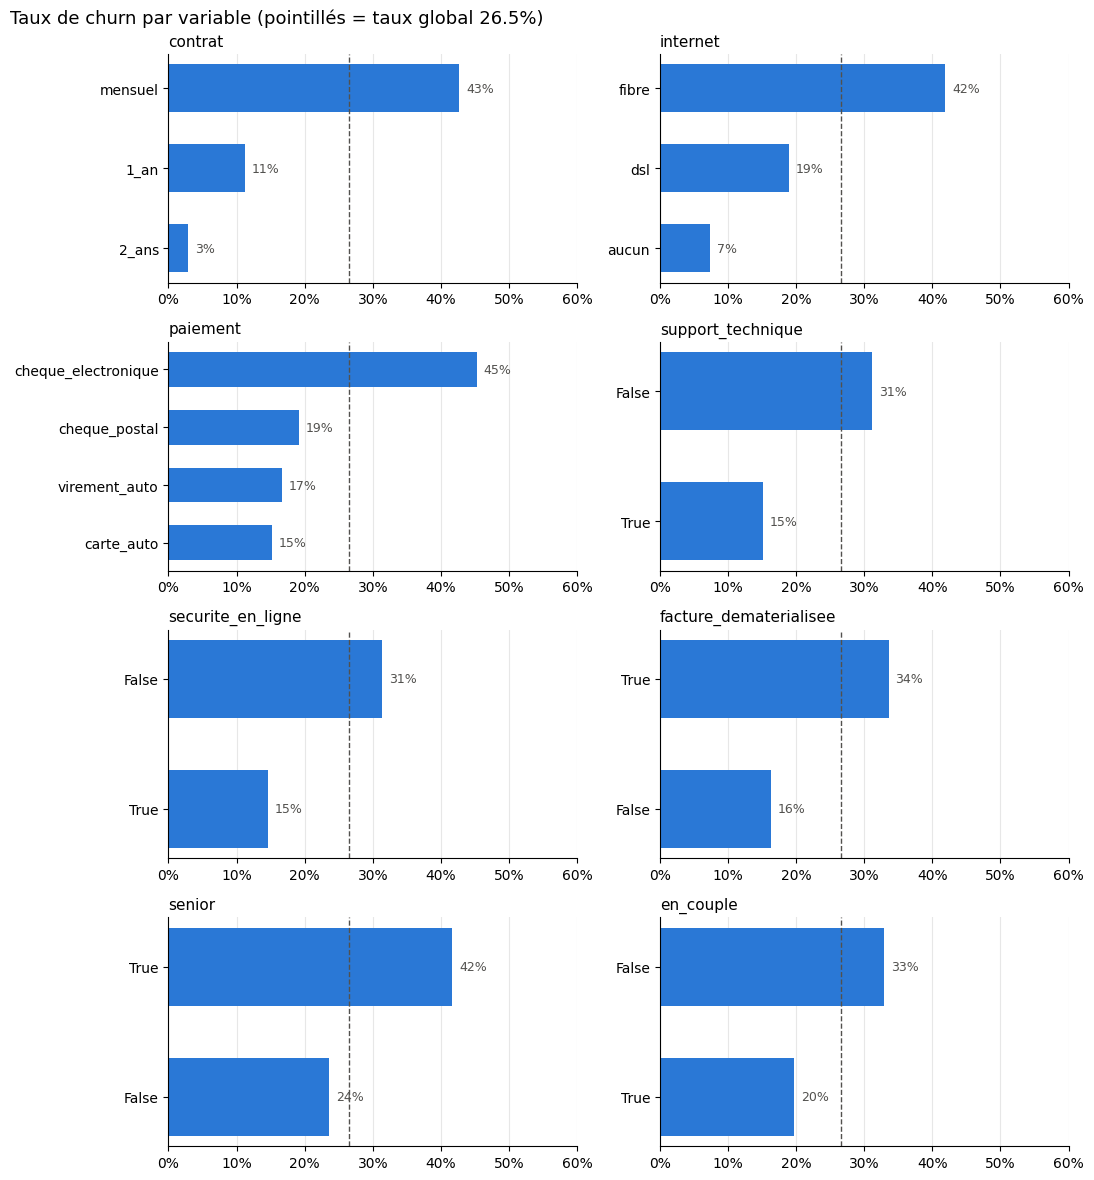

In [ ]:
CATEGORIELLES = ["contrat", "internet", "paiement", "support_technique",
                 "securite_en_ligne", "facture_dematerialisee", "senior", "en_couple"]

fig, axes = plt.subplots(4, 2, figsize=(11, 12))
for col, ax in zip(CATEGORIELLES, axes.flat):
    barres_taux(df, col, ax)
fig.suptitle(f"Taux de churn par variable (pointillés = taux global {TAUX_GLOBAL:.1%})",
             x=0.01, ha="left", fontsize=13)
fig.tight_layout()
fig.savefig(IMG / "churn_par_variable.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Les mêmes chiffres en tableau, pour les 4 variables clés
for col in ["contrat", "internet", "paiement", "support_technique"]:
    display(taux_churn_par(df, col).style.format({"taux_churn": "{:.1%}"}))

,n,taux_churn
contrat,,
mensuel,3875,42.7%
1_an,1473,11.3%
2_ans,1695,2.8%


,n,taux_churn
internet,,
fibre,3096,41.9%
dsl,2421,19.0%
aucun,1526,7.4%


,n,taux_churn
paiement,,
cheque_electronique,2365,45.3%
cheque_postal,1612,19.1%
virement_auto,1544,16.7%
carte_auto,1522,15.2%


,n,taux_churn
support_technique,,
False,4999,31.2%
True,2044,15.2%


## 3. Variables numériques : ancienneté et montant mensuel

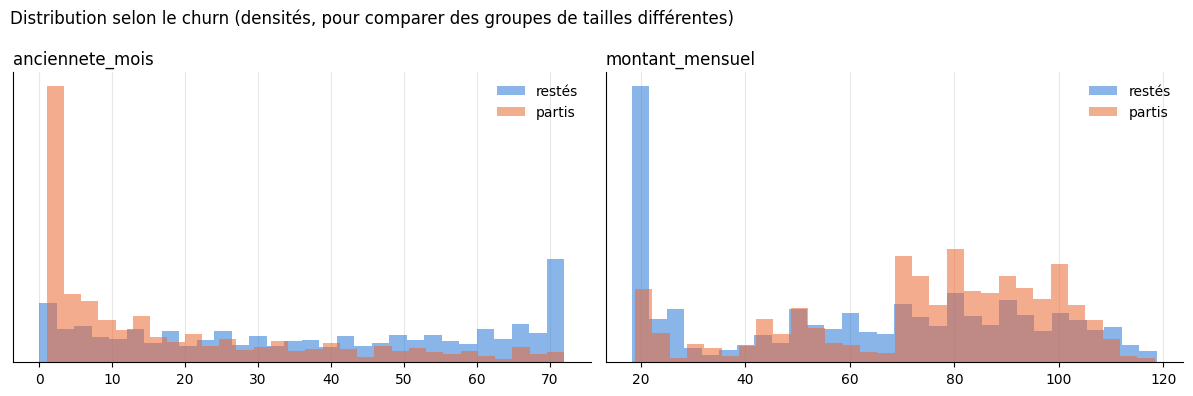

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, ax in zip(["anciennete_mois", "montant_mensuel"], axes):
    for valeur, couleur, label in [(0, BLEU, "restés"), (1, ORANGE, "partis")]:
        ax.hist(df.loc[df["churn"] == valeur, col], bins=30, density=True,
                alpha=0.55, color=couleur, label=label)
    ax.set_title(col, loc="left")
    ax.set_yticks([])
    ax.legend(frameon=False)
fig.suptitle("Distribution selon le churn (densités, pour comparer des groupes de tailles différentes)",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [ ]:
# Churn par tranche d'ancienneté
tranches = pd.cut(df["anciennete_mois"], bins=[-1, 6, 12, 24, 48, 72],
                  labels=["0-6 mois", "7-12", "13-24", "25-48", "49-72"])
taux_churn_par(df.assign(anciennete=tranches), "anciennete").sort_index() \
    .style.format({"taux_churn": "{:.1%}"})

,n,taux_churn
anciennete,,
0-6 mois,1481,52.9%
7-12,705,35.9%
13-24,1024,28.7%
25-48,1594,20.4%
49-72,2239,9.5%


## 4. Redondances entre variables

In [ ]:
num = df[["anciennete_mois", "montant_mensuel", "montant_total", "churn"]]
display(num.corr().round(2))

# montant_total ≈ ancienneté × montant mensuel ?
approx = df["anciennete_mois"] * df["montant_mensuel"]
print(f"Corrélation montant_total vs ancienneté × mensuel : {df['montant_total'].corr(approx):.3f}")

,anciennete_mois,montant_mensuel,montant_total,churn
anciennete_mois,1.00,0.25,0.83,-0.35
montant_mensuel,0.25,1.00,0.65,0.19
montant_total,0.83,0.65,1.00,-0.20
churn,-0.35,0.19,-0.20,1.00


Corrélation montant_total vs ancienneté × mensuel : 1.000


`montant_total` est presque exactement `ancienneté × montant mensuel` : il n'apporte quasiment
aucune information nouvelle et crée de la colinéarité. **On le retirera du modèle** (surtout pour la
régression logistique ; XGBoost y est moins sensible, mais ça simplifie l'interprétation SHAP).

## 5. Synthèse

| Facteur | Plus risqué | Moins risqué | Motif des avis |
|---|---|---|---|
| Contrat | mensuel **43 %** | 2 ans **3 %** | résiliation |
| Ancienneté | 0-6 mois **53 %** | 49-72 mois **10 %** | — |
| Internet | fibre **42 %** | sans internet **7 %** | réseau |
| Paiement | chèque électronique **45 %** | carte auto **15 %** | facturation |
| Facture dématérialisée | oui **34 %** | non **16 %** | facturation |
| Support technique | sans **31 %** | avec **15 %** | service client |
| Sécurité en ligne | sans **31 %** | avec **15 %** | service client |
| Senior | oui **42 %** | non **24 %** | — |

**Profil type du client qui part :** récent, sans engagement, fibre, paie par chèque électronique,
sans support technique, avec une facture mensuelle plus élevée (médiane ~80 $ contre ~64 $).

**Lien avec les avis réels :** les 4 motifs se retrouvent tous dans les données de churn
(contrat → résiliation, fibre → réseau, paiement/facture → facturation, support → service client).
La fibre est un bon exemple : c'est une offre premium, mais son taux de churn est le plus élevé,
ce qui rejoint le poids du **réseau** dans les plaintes des avis.

⚠️ Ce sont des **corrélations**, pas des causes : la fibre est liée à des factures plus élevées et à des
clients plus récents. C'est le modèle (+ SHAP) qui démêlera l'effet propre de chaque variable.

**Pour le modèle :** retirer `montant_total` (redondant), garder toutes les autres variables,
gérer le déséquilibre (26,5 % de churn).